# ForestClustering hyperparameters: an empirical tutorial

This notebook studies one parameter at a time on a synthetic mixed-type dataset with five known classes. We report:

| Quantity | Interpretation |
|---|---|
| ARI | agreement with the generator labels; available here only because this is synthetic data |
| Std(ARI) | variability of external quality across random seeds; not the same as pairwise partition stability |
| Time | local wall-clock time of `fit_predict`; machine and workload dependent |
| Memory estimate | storage order for the embedding versus an explicitly materialized pairwise matrix |

These are sensitivity experiments, not universal defaults. A one-factor sweep misses interactions, and selecting parameters by the same labels used for reporting is exploratory tuning rather than an unbiased estimate of generalization.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import math
import multiprocessing
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.metrics import adjusted_rand_score
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), ''))
from forest_clustering import ForestClusterer
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120})
N_CLUSTERS = 5
print("OK")


OK


## Dataset and reference configuration

The generator creates 2,500 observations with continuous, binary, categorical, correlated-copy, and noise features. The five labels are withheld from fitting and used only for ARI. `BASE` fixes all parameters except the one being swept and uses `n_jobs=1` for reproducible timings. Reusing one generated dataset isolates estimator randomness, while also limiting every conclusion to this single data-generating process.

In [2]:
def make_dataset(n_samples, n_clusters=5, outlier_fraction=0.0, seed=42):
    """Synthetic dataset with known clusters and mixed feature types.
    Structure:
    cont_1/2/3 — informative continuous
    binary_1/2 — informative binary
    cat_1/2 — informative categorical (4 and 5 values)
    corr_1/2 — true duplicates: corr_k ≈ cont_k + ε (sigma=0.05)
    noise_1/2/3 — pure noise
    """
    rng = np.random.default_rng(seed)
    n_out = int(n_samples * outlier_fraction)
    n_core = n_samples - n_out
    sizes = rng.multinomial(n_core, [1 / n_clusters] * n_clusters)
    centers = rng.uniform(-7, 7, (n_clusters, 3))
    for _ in range(300):
        ok = all(np.linalg.norm(centers[i] - centers[j]) >= 4
                 for i in range(n_clusters) for j in range(i + 1, n_clusters))
        if ok:
            break
        centers = rng.uniform(-7, 7, (n_clusters, 3))
    cont_parts, labels = [], []
    for k, n_k in enumerate(sizes):
        labels.extend([k] * n_k)
        cont_parts.append(rng.normal(centers[k], 0.9, (n_k, 3)))
    X_cont = np.vstack(cont_parts)
    y_core = np.array(labels)
    X_bin = np.column_stack([
        rng.binomial(1, 0.1 + 0.8 * y_core / (n_clusters - 1)),
        rng.binomial(1, 0.9 - 0.8 * y_core / (n_clusters - 1)),
    ]).astype(float)
    def cat_col(n_cats, dominant_strength=0.7):
        cols = []
        for k, n_k in enumerate(sizes):
            probs = np.full(n_cats, (1 - dominant_strength) / (n_cats - 1))
            probs[k % n_cats] = dominant_strength
            cols.append(rng.choice(n_cats, n_k, p=probs))
        return np.concatenate(cols)
    X_cat = np.column_stack([cat_col(4), cat_col(5)])
    X_corr = X_cont[:, :2] + rng.normal(0, 0.05, (n_core, 2))
    X_noise = rng.normal(0, 4, (n_core, 3))
    if n_out > 0:
        X_cont = np.vstack([X_cont, rng.uniform(-22, 22, (n_out, 3))])
        X_bin = np.vstack([X_bin, rng.binomial(1, 0.5, (n_out, 2)).astype(float)])
        X_cat = np.vstack([X_cat, np.column_stack([rng.integers(0, 4, n_out),
                                                   rng.integers(0, 5, n_out)])])
        X_corr = np.vstack([X_corr, rng.uniform(-22, 22, (n_out, 2))])
        X_noise = np.vstack([X_noise, rng.normal(0, 4, (n_out, 3))])
        y_core = np.concatenate([y_core, np.full(n_out, -1)])
    X = np.hstack([X_cont, X_bin, X_cat.astype(float), X_corr, X_noise])
    perm = rng.permutation(n_samples)
    X, y = X[perm], y_core[perm]
    COLS = ['cont_1','cont_2','cont_3',
            'binary_1','binary_2',
            'cat_1','cat_2',
            'corr_1','corr_2',
            'noise_1','noise_2','noise_3']
    df = pd.DataFrame(X, columns=COLS)
    df['cat_1'] = df['cat_1'].astype(int).map({0:'A',1:'B',2:'C',3:'D'})
    df['cat_2'] = df['cat_2'].astype(int).map({0:'v',1:'w',2:'x',3:'y',4:'z'})
    df['binary_1'] = df['binary_1'].astype(int)
    df['binary_2'] = df['binary_2'].astype(int)
    return df, y

def append_outliers(df_core, y_core, fraction, seed=2024):
    """Append contamination without changing or resampling the core rows."""
    rng = np.random.default_rng(seed)
    n_out = int(round(len(df_core) * fraction))
    if n_out == 0:
        return df_core.copy(), y_core.copy()
    outliers = pd.DataFrame({
        'cont_1': rng.uniform(-22, 22, n_out),
        'cont_2': rng.uniform(-22, 22, n_out),
        'cont_3': rng.uniform(-22, 22, n_out),
        'binary_1': rng.integers(0, 2, n_out),
        'binary_2': rng.integers(0, 2, n_out),
        'cat_1': rng.choice(list('ABCD'), n_out),
        'cat_2': rng.choice(list('vwxyz'), n_out),
        'corr_1': rng.uniform(-22, 22, n_out),
        'corr_2': rng.uniform(-22, 22, n_out),
        'noise_1': rng.normal(0, 4, n_out),
        'noise_2': rng.normal(0, 4, n_out),
        'noise_3': rng.normal(0, 4, n_out),
    })
    return (
        pd.concat([df_core, outliers], ignore_index=True),
        np.concatenate([y_core, np.full(n_out, -1, dtype=int)]),
    )
N = 2_500
N_CLUSTERS = 5
df0, y0 = make_dataset(N, N_CLUSTERS, seed=42)
COLS = df0.columns.tolist()
D = len(COLS)
print(f"n={N}, d={D}, clusters: {np.unique(y0, return_counts=True)}")
# Fixed downstream: n_clusters (default KMeans internally) — no explicit clusterer=
BASE = dict(
    n_iterations=200,
    n_bins=3,
    n_features='sqrt',
    quantile_cuts=True,
    corr_threshold=0.9,
    corr_sample_size=N,
    n_jobs=1,
)
print("Helper ready. BASE =", BASE)


n=2500, d=12, clusters: (array([0, 1, 2, 3, 4]), array([485, 471, 505, 506, 533]))
Helper ready. BASE = {'n_iterations': 200, 'n_bins': 3, 'n_features': 'sqrt', 'quantile_cuts': True, 'corr_threshold': 0.9, 'corr_sample_size': 2500, 'n_jobs': 1}


In [3]:
def run_sweep(param, values, df, y_true, base, n_seeds=3):
    """Sweep one parameter, others = base. Returns a DataFrame of results."""
    records = []
    for v in values:
        aris, times = [], []
        for s in range(n_seeds):
            clf = ForestClusterer(**{**base, param: v},
                                  n_clusters=N_CLUSTERS, random_state=s)
            t0 = time.perf_counter()
            lbl = clf.fit_predict(df)
            elapsed = time.perf_counter() - t0
            mask = lbl >= 0
            ari = adjusted_rand_score(y_true[mask], lbl[mask]) if mask.sum() > 10 else 0.0
            aris.append(ari)
            times.append(elapsed)
        records.append({
            'value': v,
            'ari_mean': np.mean(aris), 'ari_std': np.std(aris),
            'time_mean': np.mean(times), 'time_std': np.std(times),
        })
    return pd.DataFrame(records)
print("run_sweep helper defined")


run_sweep helper defined


## 1. `n_iterations`: representation size and compute budget

Each iteration adds one column to the `n × L` embedding. More iterations average over more random partitions, but downstream clustering can react non-monotonically: more columns do **not** guarantee higher ARI or lower seed variability on a finite dataset. Runtime and memory usually increase with `L`, although overhead and parallel scheduling prevent a strict linear guarantee.

In [4]:
L_vals = [10, 20, 50, 100, 150, 200, 300, 400, 500]
df_L = run_sweep('n_iterations', L_vals, df0, y0, BASE, n_seeds=5)
df_L['emb_mb'] = [N * l * 8 / 1e6 for l in L_vals]
df_L.round(4)


,value,ari_mean,ari_std,time_mean,time_std,emb_mb
0,10,0.4941,0.1637,0.0315,0.0085,0.2
1,20,0.6325,0.1201,0.0467,0.0074,0.4
2,50,0.8565,0.0599,0.0851,0.0156,1.0
3,100,0.8387,0.0960,0.1520,0.0252,2.0
4,150,0.7958,0.1231,0.2518,0.0273,3.0
5,200,0.8136,0.1367,0.3472,0.0698,4.0
6,300,0.7985,0.1418,0.4412,0.0637,6.0
7,400,0.9046,0.0187,0.5895,0.0395,8.0
8,500,0.8475,0.1085,0.6964,0.0606,10.0


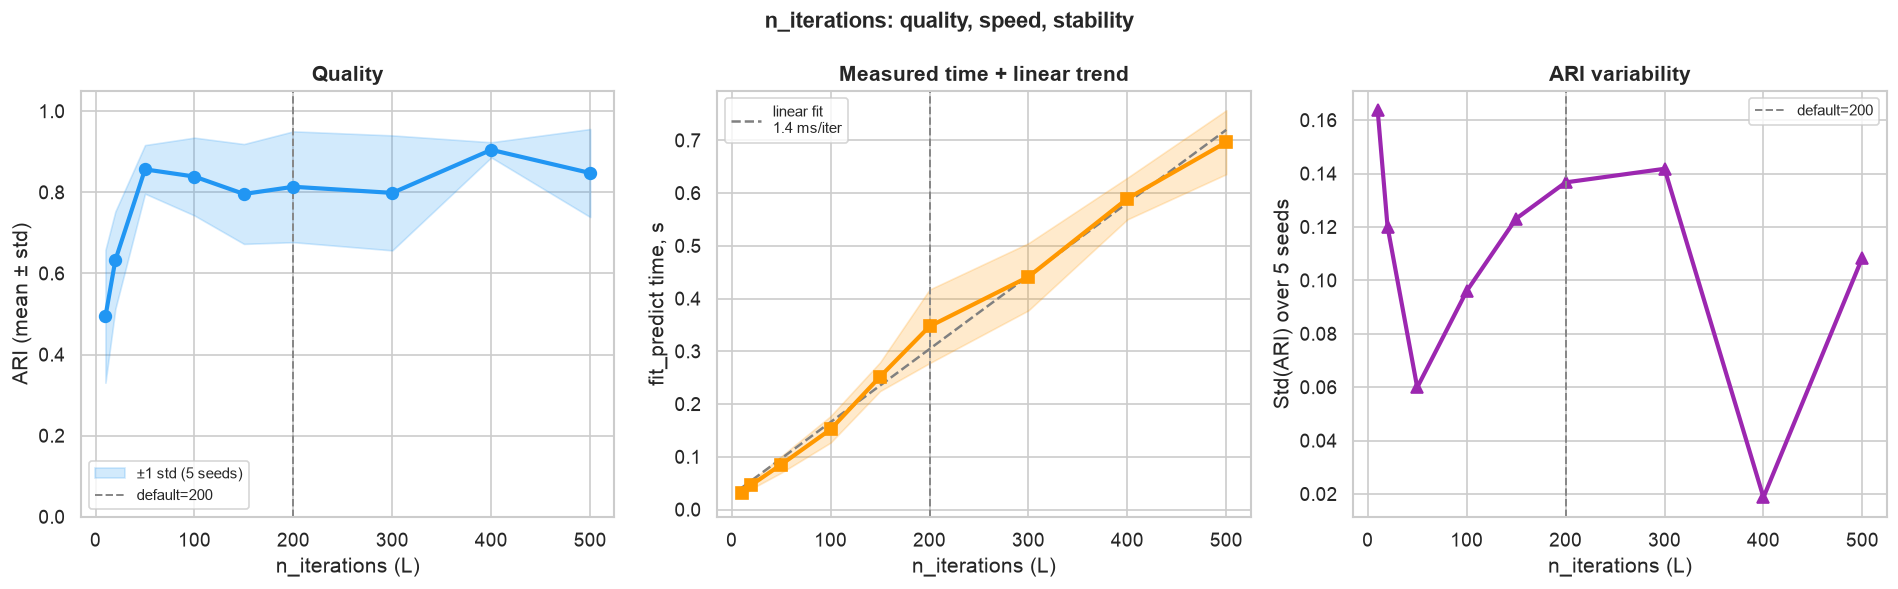

L= 50: ARI=0.856 ±0.060 t=0.09s emb=1.0MB
L=100: ARI=0.839 ±0.096 t=0.15s emb=2.0MB
L=200: ARI=0.814 ±0.137 t=0.35s emb=4.0MB
L=500: ARI=0.847 ±0.109 t=0.70s emb=10.0MB
Highest observed mean ARI: L=400 (0.905); the curve is not assumed monotonic.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# ARI with ±std band
ax = axes[0]
ax.plot(df_L.value, df_L.ari_mean, 'o-', color='#2196F3', lw=2.5, ms=7, zorder=3)
ax.fill_between(df_L.value,
                df_L.ari_mean - df_L.ari_std,
                df_L.ari_mean + df_L.ari_std,
                alpha=0.2, color='#2196F3', label='±1 std (5 seeds)')
ax.axvline(200, color='#888', ls='--', lw=1.2, label='default=200')
ax.set_xlabel('n_iterations (L)')
ax.set_ylabel('ARI (mean ± std)')
ax.set_title('Quality', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
# Time with linear fit
ax = axes[1]
ax.plot(df_L.value, df_L.time_mean, 's-', color='#FF9800', lw=2.5, ms=7, zorder=3)
ax.fill_between(df_L.value,
                df_L.time_mean - df_L.time_std,
                df_L.time_mean + df_L.time_std,
                alpha=0.2, color='#FF9800')
coeffs = np.polyfit(df_L.value, df_L.time_mean, 1)
x_fit = np.linspace(df_L.value.min(), df_L.value.max(), 200)
ax.plot(x_fit, np.polyval(coeffs, x_fit), '--', color='gray', lw=1.5,
        label=f'linear fit\n{coeffs[0]*1000:.1f} ms/iter')
ax.axvline(200, color='#888', ls='--', lw=1.2)
ax.set_xlabel('n_iterations (L)')
ax.set_ylabel('fit_predict time, s')
ax.set_title('Measured time + linear trend', fontweight='bold')
ax.legend(fontsize=9)
# Stability (std ARI)
ax = axes[2]
ax.plot(df_L.value, df_L.ari_std, '^-', color='#9C27B0', lw=2.5, ms=7)
ax.axvline(200, color='#888', ls='--', lw=1.2, label='default=200')
ax.set_xlabel('n_iterations (L)')
ax.set_ylabel('Std(ARI) over 5 seeds')
ax.set_title('ARI variability', fontweight='bold')
ax.legend(fontsize=9)
plt.suptitle('n_iterations: quality, speed, stability', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
for l in [50, 100, 200, 500]:
    row = df_L[df_L.value == l].iloc[0]
    print(f"L={l:3d}: ARI={row.ari_mean:.3f} ±{row.ari_std:.3f} "
          f"t={row.time_mean:.2f}s emb={row.emb_mb:.1f}MB")
best_L = df_L.loc[df_L.ari_mean.idxmax()]
print(f'Highest observed mean ARI: L={int(best_L.value)} ({best_L.ari_mean:.3f}); the curve is not assumed monotonic.')


## 2. `n_bins`: partition granularity

With `M` selected features, `K**M` is an **upper bound** on the number of joint cells in an iteration, not the observed count. `n / K**M` is therefore only a uniform-occupancy heuristic. Small `K` can be coarse; large `K` can make co-membership rare. Neither statement identifies an optimum without measurement, and on this dataset the best mean ARI need not occur at the default `K=3`.

In [6]:
K_vals = [2, 3, 4, 5, 6, 7, 8]
df_K = run_sweep('n_bins', K_vals, df0, y0, BASE, n_seeds=3)
M_default = math.ceil(math.sqrt(D))
df_K['cells_per_iter'] = [k ** M_default for k in K_vals]
df_K['avg_pts_cell'] = N / df_K['cells_per_iter']
df_K[['value','ari_mean','ari_std','cells_per_iter','avg_pts_cell','time_mean']].round(3)


,value,ari_mean,ari_std,cells_per_iter,avg_pts_cell,time_mean
0,2,0.795,0.017,16,156.250,0.157
1,3,0.807,0.160,81,30.864,0.323
2,4,0.807,0.162,256,9.766,0.496
3,5,0.819,0.138,625,4.000,0.771
4,6,0.721,0.149,1296,1.929,1.010
5,7,0.660,0.116,2401,1.041,1.299
6,8,0.833,0.149,4096,0.610,1.505


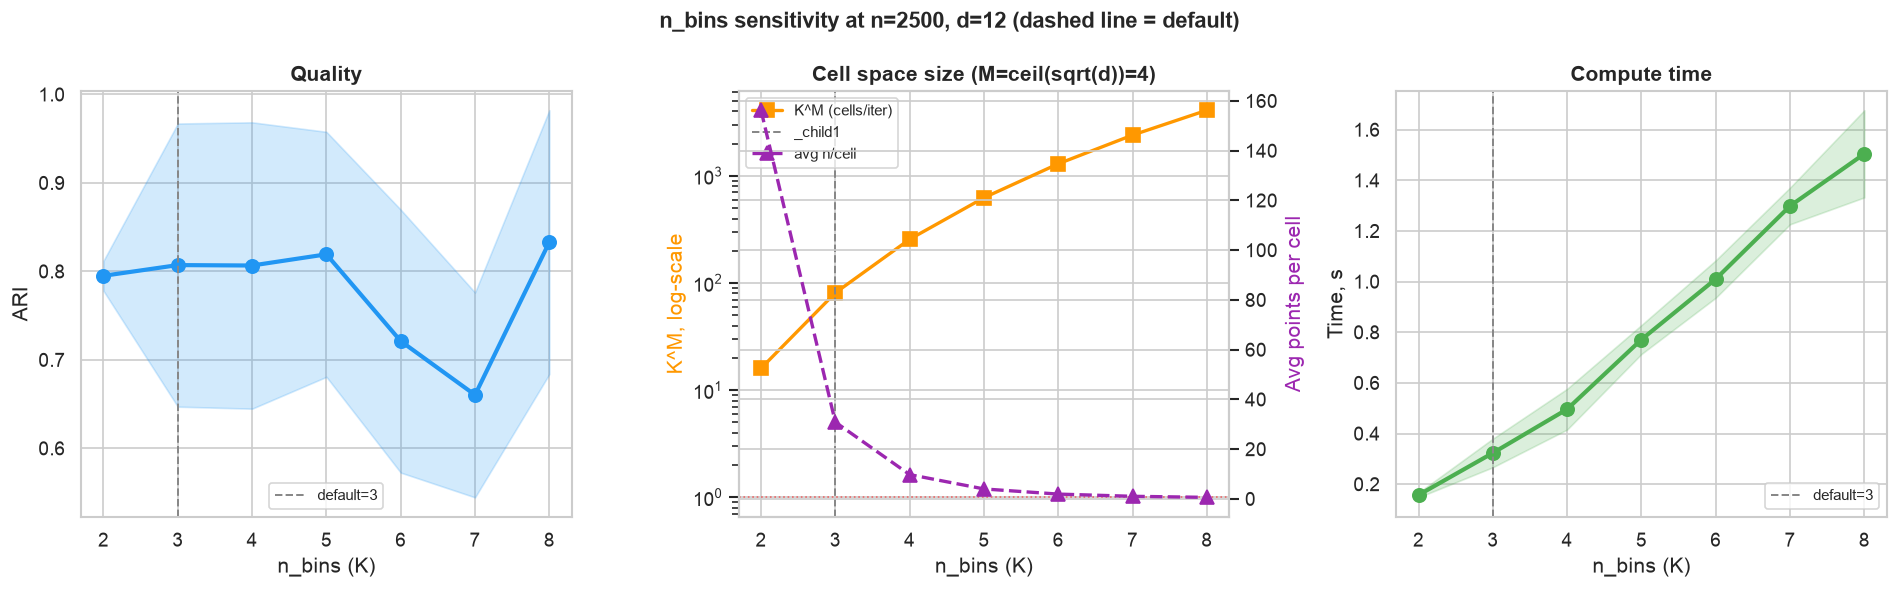

Highest observed mean ARI: K=8 (0.833).


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# ARI
ax = axes[0]
ax.plot(df_K.value, df_K.ari_mean, 'o-', color='#2196F3', lw=2.5, ms=8)
ax.fill_between(df_K.value, df_K.ari_mean - df_K.ari_std,
                df_K.ari_mean + df_K.ari_std, alpha=0.2, color='#2196F3')
ax.axvline(3, color='#888', ls='--', lw=1.2, label='default=3')
ax.set_xlabel('n_bins (K)')
ax.set_ylabel('ARI')
ax.set_title('Quality', fontweight='bold')
ax.set_xticks(K_vals)
ax.legend(fontsize=9)
# Cell space size
ax = axes[1]
ax_r = ax.twinx()
ax.semilogy(df_K.value, df_K.cells_per_iter, 's-', color='#FF9800', lw=2, ms=8,
            label='K^M (cells/iter)')
ax_r.plot(df_K.value, df_K.avg_pts_cell, '^--', color='#9C27B0', lw=2, ms=8,
          label='avg n/cell')
ax.set_xlabel('n_bins (K)')
ax.set_ylabel('K^M, log-scale', color='#FF9800')
ax_r.set_ylabel('Avg points per cell', color='#9C27B0')
ax.set_title(f'Cell space size (M=ceil(sqrt(d))={M_default})', fontweight='bold')
ax.axvline(3, color='#888', ls='--', lw=1.2)
ax.set_xticks(K_vals)
lines = ax.get_lines() + ax_r.get_lines()
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, fontsize=9, loc='upper left')
ax.axhline(1, color='red', ls=':', lw=1, alpha=0.5)
# Time
ax = axes[2]
ax.plot(df_K.value, df_K.time_mean, 'o-', color='#4CAF50', lw=2.5, ms=8)
ax.fill_between(df_K.value, df_K.time_mean - df_K.time_std,
                df_K.time_mean + df_K.time_std, alpha=0.2, color='#4CAF50')
ax.axvline(3, color='#888', ls='--', lw=1.2, label='default=3')
ax.set_xlabel('n_bins (K)')
ax.set_ylabel('Time, s')
ax.set_title('Compute time', fontweight='bold')
ax.set_xticks(K_vals)
ax.legend(fontsize=9)
plt.suptitle(f'n_bins sensitivity at n={N}, d={D} (dashed line = default)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
best_K = df_K.loc[df_K.ari_mean.idxmax()]
print(f'Highest observed mean ARI: K={int(best_K.value)} ({best_K.ari_mean:.3f}).')


## 3. `n_features`: feature subspace size

This controls how many features participate in one random partition. Small subspaces emphasize marginal structure; large subspaces encode more interactions but reduce diversity and create sparser joint cells. `'sqrt'` is a reasonable starting heuristic, not a mathematical optimum. The sweep below deliberately includes `M=1` and all features so the data can contradict the heuristic.

In [8]:
nf_options = [1, 2, 'log2', 'sqrt', 6, 0.5, 1.0]
def resolve_M(val, d):
    if val == 'sqrt': return math.ceil(math.sqrt(d))
    if val == 'log2': return max(1, math.ceil(math.log2(d)))
    if isinstance(val, float): return max(1, int(val * d))
    return int(val)
nf_rows = []
for val in nf_options:
    aris, times = [], []
    for s in range(3):
        clf = ForestClusterer(**{**BASE, 'n_features': val},
                              n_clusters=N_CLUSTERS, random_state=s)
        t0 = time.perf_counter()
        lbl = clf.fit_predict(df0)
        elapsed = time.perf_counter() - t0
        aris.append(adjusted_rand_score(y0, lbl))
        times.append(elapsed)
    m_val = resolve_M(val, D)
    label = str(val) if not isinstance(val, float) else f'{val}*d={m_val}'
    if val == 'sqrt': label = f"sqrt ≈ {m_val}"
    if val == 'log2': label = f"log2 ≈ {m_val}"
    nf_rows.append({
        'option': label, 'M': m_val,
        'ari_mean': np.mean(aris), 'ari_std': np.std(aris),
        'time_mean': np.mean(times), 'time_std': np.std(times),
    })
df_M = pd.DataFrame(nf_rows)
df_M[['option','M','ari_mean','ari_std','time_mean']].round(3)


,option,M,ari_mean,ari_std,time_mean
0,1,1,0.844,0.119,0.039
1,2,2,0.836,0.117,0.080
2,log2 ≈ 4,4,0.807,0.160,0.311
3,sqrt ≈ 4,4,0.807,0.160,0.302
4,6,6,0.465,0.083,1.469
5,0.5*d=6,6,0.465,0.083,1.425
6,1.0*d=12,12,0.020,0.013,9.295


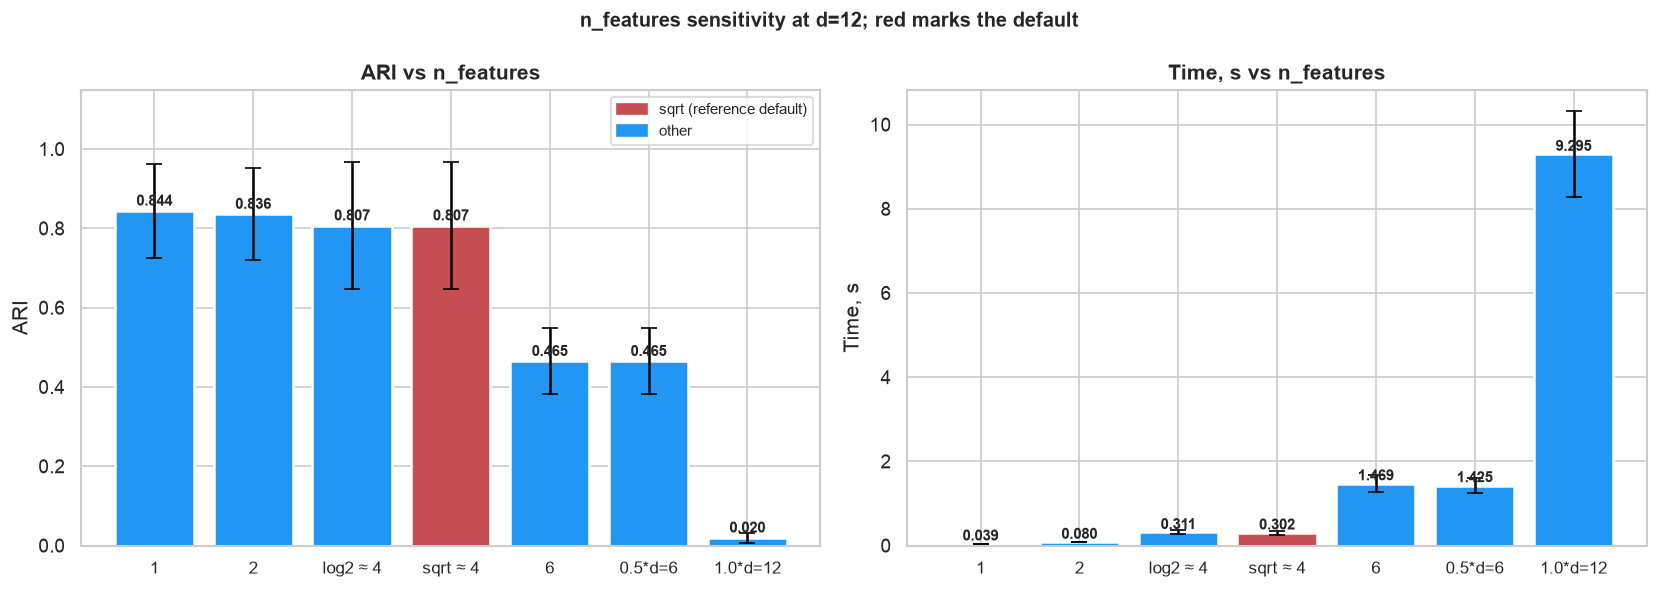

Highest observed mean ARI: 1 (0.844).


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(df_M))
def_idx = [i for i, r in df_M.iterrows() if 'sqrt' in str(r.option)][0]
colors_nf = ['#C44E52' if i == def_idx else '#2196F3' for i in x]
for ax_i, (col, label) in enumerate([('ari_mean', 'ARI'), ('time_mean', 'Time, s')]):
    ax = axes[ax_i]
    bars = ax.bar(x, df_M[col], color=colors_nf, edgecolor='white', linewidth=1.5)
    err = 'ari_std' if ax_i == 0 else 'time_std'
    ax.errorbar(x, df_M[col], yerr=df_M[err], fmt='none',
                color='black', capsize=5, lw=1.5)
    for bar, v in zip(bars, df_M[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df_M.option, fontsize=10)
    ax.set_ylabel(label)
    ax.set_title(f'{label} vs n_features', fontweight='bold')
    if ax_i == 0:
        ax.set_ylim(0, 1.15)
        ax.legend(handles=[Patch(color='#C44E52', label='sqrt (reference default)'),
                           Patch(color='#2196F3', label='other')], fontsize=9)
plt.suptitle(f'n_features sensitivity at d={D}; red marks the default',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
best_M = df_M.loc[df_M.ari_mean.idxmax()]
print(f'Highest observed mean ARI: {best_M.option} ({best_M.ari_mean:.3f}).')


## 4. `quantile_cuts`: sensitivity to appended outliers

The implementation samples random cut points either uniformly over the observed `[min, max]` range or at random empirical quantiles. An extreme value can stretch the uniform range, causing many ordinary values to share a bin; for that feature their pairwise Hamming contribution then tends toward **0**, not 1. Quantile cuts bound this magnitude effect, but empirical quantiles can still move and labels are not guaranteed to remain unchanged.

For a valid contamination curve we append outliers to one fixed clean dataset and score those exact original rows. The result is specific to this outlier generator and should be read from the curve, not assumed in advance.

In [10]:
out_fracs = [0.0, 0.03, 0.05, 0.10, 0.15, 0.20]
qc_rows = []
for frac in out_fracs:
    df_o, y_o = append_outliers(df0, y0, fraction=frac)
    clean_mask = y_o >= 0
    assert df_o.loc[clean_mask].reset_index(drop=True).equals(df0.reset_index(drop=True))
    for qc in [False, True]:
        aris = []
        for s in range(3):
            clf = ForestClusterer(**{**BASE, 'quantile_cuts': qc},
                                  n_clusters=N_CLUSTERS, random_state=s)
            lbl = clf.fit_predict(df_o)
            aris.append(adjusted_rand_score(y_o[clean_mask], lbl[clean_mask]))
        qc_rows.append({'frac': frac, 'qc': qc,
                        'ari_mean': np.mean(aris), 'ari_std': np.std(aris)})
df_qc = pd.DataFrame(qc_rows)
print(df_qc.pivot(index='frac', columns='qc', values='ari_mean').round(3))


qc    False  True 
frac              
0.00  0.815  0.807
0.03  0.571  0.802
0.05  0.722  0.847
0.10  0.711  0.910
0.15  0.755  0.900
0.20  0.645  0.791


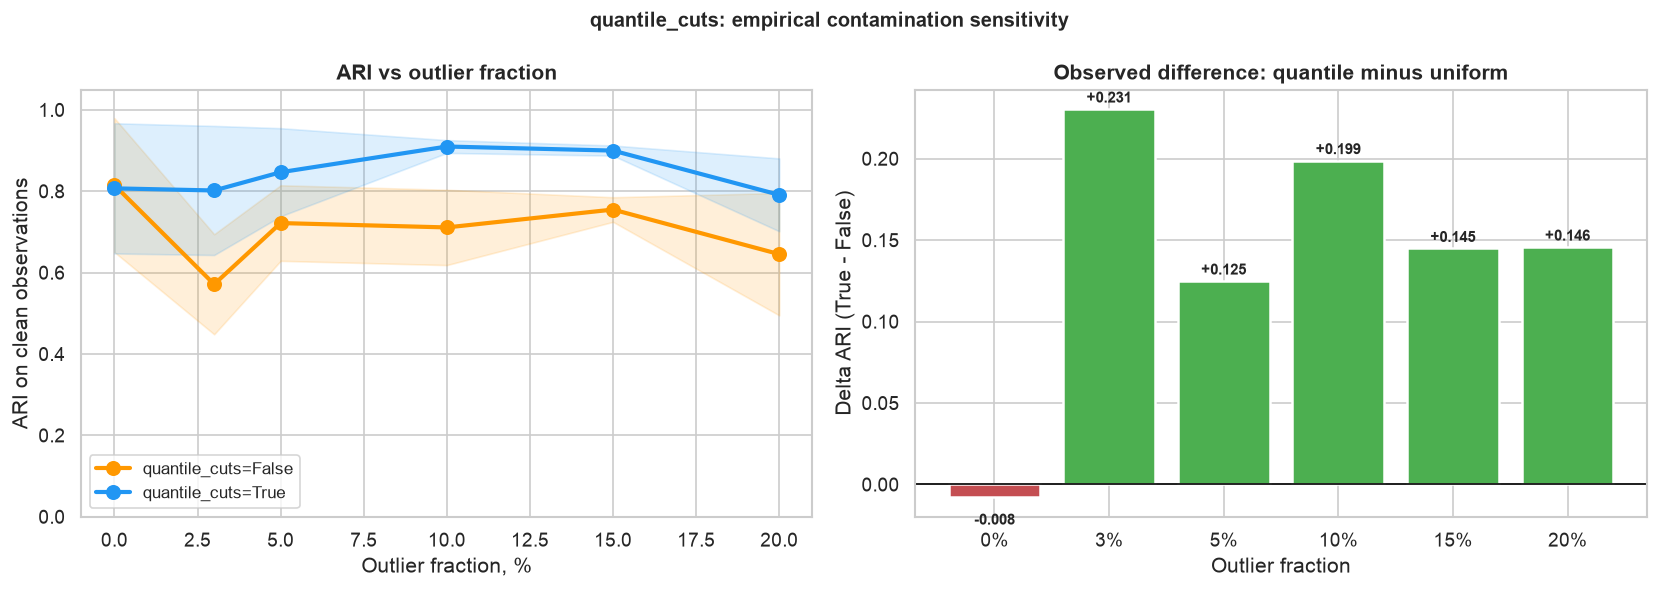

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
colors_qc = {False: '#FF9800', True: '#2196F3'}
labels_qc = {False: 'quantile_cuts=False', True: 'quantile_cuts=True'}
for qc in [False, True]:
    sub = df_qc[df_qc.qc == qc]
    ax.plot(sub.frac * 100, sub.ari_mean, 'o-', color=colors_qc[qc],
            lw=2.5, ms=8, label=labels_qc[qc])
    ax.fill_between(sub.frac * 100,
                    sub.ari_mean - sub.ari_std,
                    sub.ari_mean + sub.ari_std,
                    alpha=0.15, color=colors_qc[qc])
ax.set_xlabel('Outlier fraction, %')
ax.set_ylabel('ARI on clean observations')
ax.set_title('ARI vs outlier fraction', fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
# Delta ARI (True - False)
ax = axes[1]
deltas = (df_qc[df_qc.qc == True].ari_mean.values -
          df_qc[df_qc.qc == False].ari_mean.values)
ax.bar([f'{f*100:.0f}%' for f in out_fracs], deltas,
       color=['#4CAF50' if d >= 0 else '#C44E52' for d in deltas],
       edgecolor='white', linewidth=1.5)
for i, (d, frac) in enumerate(zip(deltas, out_fracs)):
    ax.text(i, d + (0.002 if d >= 0 else -0.01),
            f'{d:+.3f}', ha='center',
            va='bottom' if d >= 0 else 'top',
            fontsize=9, fontweight='bold')
ax.axhline(0, color='black', lw=1)
ax.set_xlabel('Outlier fraction')
ax.set_ylabel('Delta ARI (True - False)')
ax.set_title('Observed difference: quantile minus uniform', fontweight='bold')
plt.suptitle('quantile_cuts: empirical contamination sensitivity',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. `corr_threshold`: redundancy versus predictive emphasis

Features placed in a correlated group receive weight `1 / G`. The synthetic data contain near-duplicates (`corr_1 ≈ cont_1`, `corr_2 ≈ cont_2`) as well as correlations induced by the shared latent class. A low threshold may merge distinct informative variables.

De-duplicating features is an interpretability/redundancy choice, not a promise of higher ARI. In this benchmark the duplicates are informative, so disabling weighting can improve agreement with the labels by giving that signal extra influence. `None` means detection is disabled; it is not numerically equivalent to threshold 1.0.

In [12]:
thresholds = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
wt_records = []
ari_thr = []
for thr in thresholds:
    clf_w = ForestClusterer(**{**BASE, 'corr_threshold': thr},
                            n_clusters=N_CLUSTERS, random_state=42)
    clf_w.fit(df0)
    wt_records.append(dict(zip(COLS, clf_w.feature_weights_.round(3))))
    aris = []
    for s in range(3):
        clf_a = ForestClusterer(**{**BASE, 'corr_threshold': thr},
                                  n_clusters=N_CLUSTERS, random_state=s)
        aris.append(adjusted_rand_score(y0, clf_a.fit_predict(df0)))
    ari_thr.append({'thr': thr, 'ari_mean': np.mean(aris), 'ari_std': np.std(aris)})
# Add None (disabled)
clf_none = ForestClusterer(**{**BASE, 'corr_threshold': None},
                             n_clusters=N_CLUSTERS, random_state=42)
clf_none.fit(df0)
wt_records.append(dict(zip(COLS, clf_none.feature_weights_.round(3))))
aris_none = [adjusted_rand_score(y0,
             ForestClusterer(**{**BASE, 'corr_threshold': None},
                             n_clusters=N_CLUSTERS,
                             random_state=s).fit_predict(df0)) for s in range(3)]
ari_thr.append({'thr': 'None', 'ari_mean': np.mean(aris_none), 'ari_std': np.std(aris_none)})
thresholds_all = thresholds + ['None']
df_wt = pd.DataFrame(wt_records, index=[str(t) for t in thresholds_all])
df_atr = pd.DataFrame(ari_thr)
from scipy.stats import spearmanr
sp_c1_cr1 = spearmanr(df0['cont_1'], df0['corr_1']).statistic
sp_c1_c2 = spearmanr(df0['cont_1'], df0['cont_2']).statistic
print(f"Spearman(cont_1, corr_1) = {sp_c1_cr1:.3f} <- true duplicate")
print(f"Spearman(cont_1, cont_2) = {sp_c1_c2:.3f} <- ecological correlation")


Spearman(cont_1, corr_1) = 1.000 <- true duplicate
Spearman(cont_1, cont_2) = -0.323 <- ecological correlation


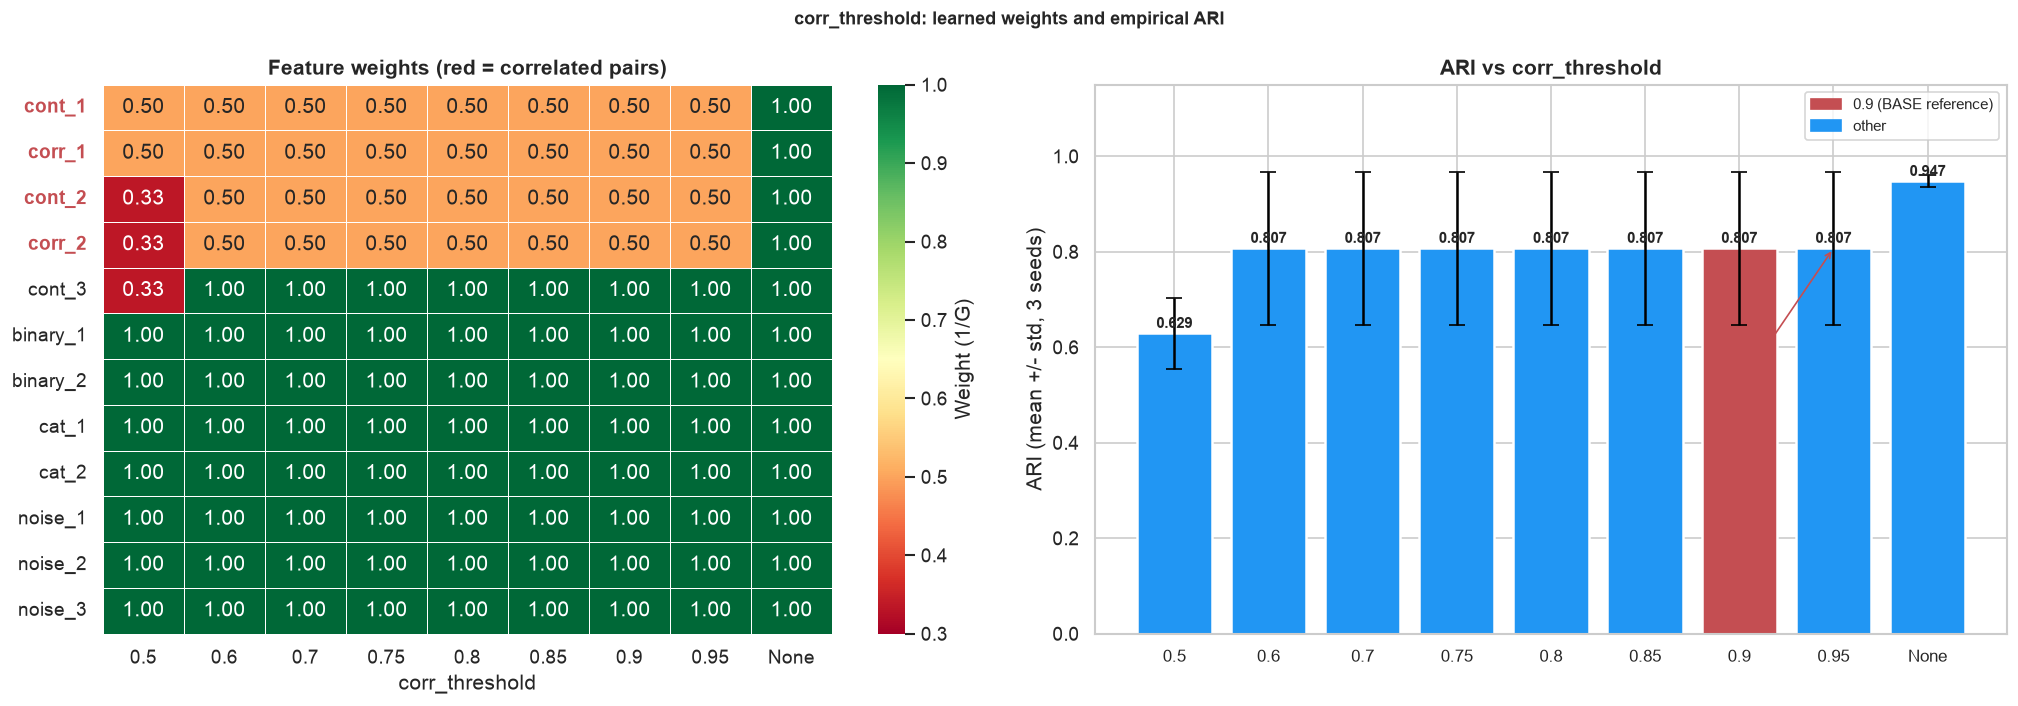


Note: corr_threshold=None (no weighting) can give high ARI
when duplicates are informative features (they get double weight).
Weighting matters most at high d where duplicates crowd out other informative features.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
# Feature weight heatmap
ax = axes[0]
feat_order = ['cont_1','corr_1','cont_2','corr_2','cont_3',
              'binary_1','binary_2','cat_1','cat_2',
              'noise_1','noise_2','noise_3']
sns.heatmap(df_wt[feat_order].T, annot=True, fmt='.2f',
            cmap='RdYlGn', vmin=0.3, vmax=1.0, ax=ax,
            linewidths=0.4, cbar_kws={'label': 'Weight (1/G)'})
ax.set_title('Feature weights per threshold', fontweight='bold')
ax.set_xlabel('corr_threshold')
ax.set_ylabel('')
for feat in ['cont_1','corr_1','cont_2','corr_2']:
    idx = feat_order.index(feat)
    ax.get_yticklabels()[idx].set_color('#C44E52')
    ax.get_yticklabels()[idx].set_fontweight('bold')
ax.set_title('Feature weights (red = correlated pairs)', fontweight='bold')
# ARI vs threshold
ax = axes[1]
x_thr = np.arange(len(df_atr))
bar_colors = ['#C44E52' if t == 0.9 else '#2196F3' for t in thresholds_all]
bars = ax.bar(x_thr, df_atr.ari_mean, color=bar_colors,
              edgecolor='white', linewidth=1.5)
ax.errorbar(x_thr, df_atr.ari_mean, yerr=df_atr.ari_std,
            fmt='none', color='black', capsize=5, lw=1.5)
for bar, v in zip(bars, df_atr.ari_mean):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x_thr)
ax.set_xticklabels([str(t) for t in thresholds_all], fontsize=10)
ax.set_ylabel('ARI (mean +/- std, 3 seeds)')
ax.set_title('ARI vs corr_threshold', fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(handles=[Patch(color='#C44E52', label='0.9 (BASE reference)'),
                   Patch(color='#2196F3', label='other')], fontsize=9)
thr_caught = max(t for t in thresholds if t <= abs(sp_c1_cr1))
ax.annotate(f'cont↔corr\ndetected', color='#C44E52',
            xy=(thresholds.index(thr_caught), df_atr.iloc[thresholds.index(thr_caught)].ari_mean),
            xytext=(thresholds.index(thr_caught) - 1.3, 0.5),
            arrowprops=dict(arrowstyle='->', color='#C44E52'),
            fontsize=8)
plt.suptitle('corr_threshold: learned weights and empirical ARI',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
print("\nNote: corr_threshold=None (no weighting) can give high ARI")
print("when duplicates are informative features (they get double weight).")
print("Weighting matters most at high d where duplicates crowd out other informative features.")


## 6. `n_jobs`: measure parallel overhead

Iterations can be scheduled in parallel, but speedup depends on Python overhead, memory bandwidth, backend behaviour, dataset size, and the host's logical-versus-physical core count. Near-linear speedup is **not** expected by default; on a modest workload, `n_jobs=1` can be fastest. Use this sweep on the target machine before choosing `-1`.

In [14]:
N_LARGE = 25_000
df_lg, _ = make_dataset(N_LARGE, N_CLUSTERS, seed=7)
n_cpu = multiprocessing.cpu_count()
print(f"Cores: {n_cpu}, n={N_LARGE}, L=200")
jobs_grid = sorted(set([1, 2, min(4, n_cpu), min(8, n_cpu), n_cpu]))
job_rows = []
for n_jobs in jobs_grid:
    times_j = []
    for _ in range(3):
        clf = ForestClusterer(**{**BASE, 'n_jobs': n_jobs, 'n_iterations': 200},
                              n_clusters=N_CLUSTERS, random_state=42)
        t0 = time.perf_counter()
        clf.fit(df_lg)
        times_j.append(time.perf_counter() - t0)
    label = f'{n_jobs}\n(all)' if n_jobs == n_cpu else str(n_jobs)
    job_rows.append({'n_jobs': n_jobs, 'label': label,
                     'time': np.mean(times_j), 'std': np.std(times_j)})
df_jobs = pd.DataFrame(job_rows)
t1 = df_jobs[df_jobs.n_jobs == 1]['time'].values[0]
df_jobs['speedup'] = t1 / df_jobs['time']
df_jobs['efficiency'] = df_jobs.speedup / df_jobs.n_jobs
df_jobs.round(3)


Cores: 14, n=25000, L=200


,n_jobs,label,time,std,speedup,efficiency
0,1,1,0.543,0.006,1.000,1.000
1,2,2,0.535,0.021,1.014,0.507
2,4,4,0.524,0.005,1.034,0.259
3,8,8,0.591,0.032,0.918,0.115
4,14,14\n(all),0.566,0.005,0.958,0.068


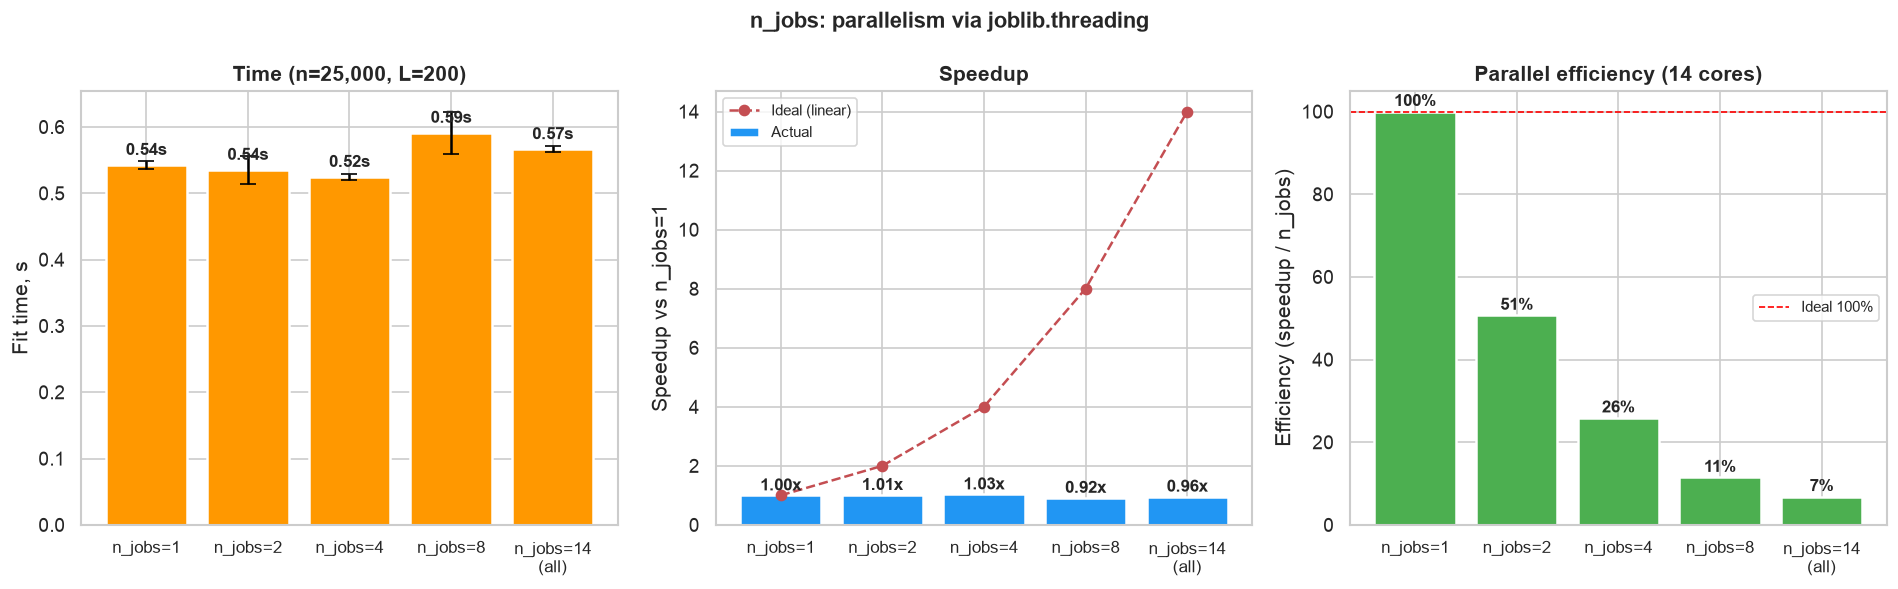

Fastest measured setting: n_jobs=4 (0.524s).


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# Time
ax = axes[0]
ax.bar(range(len(df_jobs)), df_jobs['time'], color='#FF9800', edgecolor='white', linewidth=1.5)
ax.errorbar(range(len(df_jobs)), df_jobs['time'], yerr=df_jobs['std'],
            fmt='none', color='black', capsize=5, lw=1.5)
for i, (_, row) in enumerate(df_jobs.iterrows()):
    ax.text(i, row['time'] + 0.01, f'{row["time"]:.2f}s',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(df_jobs)))
ax.set_xticklabels([f'n_jobs={l}' for l in df_jobs.label], fontsize=10)
ax.set_ylabel('Fit time, s')
ax.set_title(f'Time (n={N_LARGE:,}, L=200)', fontweight='bold')
# Speedup
ax = axes[1]
ax.bar(range(len(df_jobs)), df_jobs.speedup, color='#2196F3',
       edgecolor='white', linewidth=1.5, label='Actual')
ax.plot(range(len(df_jobs)), df_jobs.n_jobs, 'r--o', ms=6, lw=1.5,
        label='Ideal (linear)')
for i, (_, row) in enumerate(df_jobs.iterrows()):
    ax.text(i, row.speedup + 0.05, f'{row.speedup:.2f}x',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(df_jobs)))
ax.set_xticklabels([f'n_jobs={l}' for l in df_jobs.label], fontsize=10)
ax.set_ylabel('Speedup vs n_jobs=1')
ax.set_title('Speedup', fontweight='bold')
ax.legend(fontsize=9)
# Efficiency
ax = axes[2]
ax.bar(range(len(df_jobs)), df_jobs.efficiency * 100, color='#4CAF50',
       edgecolor='white', linewidth=1.5)
for i, (_, row) in enumerate(df_jobs.iterrows()):
    ax.text(i, row.efficiency * 100 + 0.5, f'{row.efficiency*100:.0f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.axhline(100, color='red', ls='--', lw=1, label='Ideal 100%')
ax.set_xticks(range(len(df_jobs)))
ax.set_xticklabels([f'n_jobs={l}' for l in df_jobs.label], fontsize=10)
ax.set_ylabel('Efficiency (speedup / n_jobs)')
ax.set_title(f'Parallel efficiency ({n_cpu} cores)', fontweight='bold')
ax.legend(fontsize=9)
plt.suptitle('n_jobs: parallelism via joblib.threading',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
fastest_jobs = df_jobs.loc[df_jobs.time.idxmin()]
print(f'Fastest measured setting: n_jobs={int(fastest_jobs.n_jobs)} ({fastest_jobs.time:.3f}s).')


## 7. Memory: embedding versus pairwise distances

The stored embedding is `n × L` (currently `int64`). A dense pairwise matrix is `n × n` and is created only by APIs/backends that request it. KMeans and MiniBatchKMeans on the embedding avoid that matrix. This distinction does **not** make every downstream method linear-memory: dense pairwise distances, agglomerative methods, and dense-neighbourhood DBSCAN can still become quadratic in the worst case. Sparse graph construction also has its own connectivity/approximation trade-offs.

        Embedding n×L, MB  Matrix n×n, GB
n                                        
1000                  1.6           0.004
5000                  8.0           0.100
10000                16.0           0.400
50000                80.0          10.000
100000              160.0          40.000
500000              800.0        1000.000


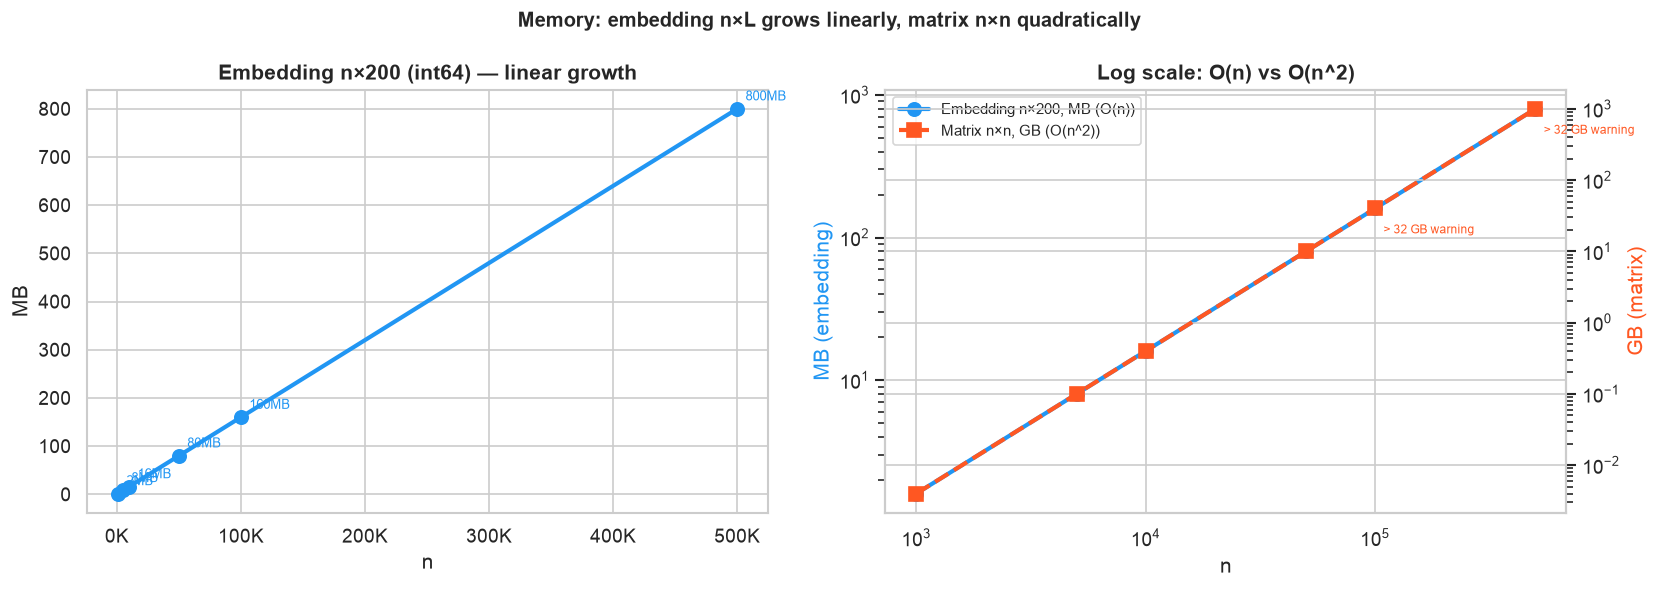


Memory-safe starting points:
 - prefer KMeans/MiniBatchKMeans on the embedding when n is large
 - use dense precomputed distances only after checking n² memory explicitly
 - benchmark DBSCAN neighbourhood density and sparse-graph connectivity on your data


In [16]:
n_vals = [1_000, 5_000, 10_000, 50_000, 100_000, 500_000]
L_fixed = 200
mem_rows = []
for n in n_vals:
    emb_mb = n * L_fixed * 8 / 1e6
    dist_gb = n * n * 4 / 1e9
    mem_rows.append({
        'n': n,
        'Embedding n×L, MB': emb_mb,
        'Matrix n×n, GB': dist_gb,
    })
df_mem = pd.DataFrame(mem_rows).set_index('n')
print(df_mem.to_string())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Linear scale (embedding)
ax = axes[0]
ax.plot(n_vals, df_mem['Embedding n×L, MB'], 'o-',
        color='#2196F3', lw=2.5, ms=8, label=f'Embedding n×{L_fixed}, MB')
for x_pt, y_pt in zip(n_vals, df_mem['Embedding n×L, MB']):
    ax.annotate(f'{y_pt:.0f}MB', (x_pt, y_pt), xytext=(5, 5),
                textcoords='offset points', fontsize=8, color='#2196F3')
ax.set_xlabel('n')
ax.set_ylabel('MB')
ax.set_title(f'Embedding n×{L_fixed} (int64) — linear growth', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
# Log scale (both)
ax = axes[1]
ax.loglog(n_vals, df_mem['Embedding n×L, MB'], 'o-',
          color='#2196F3', lw=2.5, ms=8, label=f'Embedding n×{L_fixed}, MB (O(n))')
ax2 = ax.twinx()
ax2.loglog(n_vals, df_mem['Matrix n×n, GB'], 's--',
           color='#FF5722', lw=2.5, ms=8, label='Matrix n×n, GB (O(n^2))')
ax.set_xlabel('n')
ax.set_ylabel('MB (embedding)', color='#2196F3')
ax2.set_ylabel('GB (matrix)', color='#FF5722')
ax.set_title('Log scale: O(n) vs O(n^2)', fontweight='bold')
lines = ax.get_lines() + ax2.get_lines()
ax.legend(lines, [l.get_label() for l in lines], fontsize=9, loc='upper left')
for n, gbs in zip(n_vals, df_mem['Matrix n×n, GB']):
    if gbs > 32:
        ax2.annotate('> 32 GB warning', (n, gbs), xytext=(5, -15),
                     textcoords='offset points', fontsize=7, color='#FF5722')
plt.suptitle('Memory: embedding n×L grows linearly, matrix n×n quadratically',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("\nMemory-safe starting points:")
print(" - prefer KMeans/MiniBatchKMeans on the embedding when n is large")
print(" - use dense precomputed distances only after checking n² memory explicitly")
print(" - benchmark DBSCAN neighbourhood density and sparse-graph connectivity on your data")


## 8. Optional mechanisms

The following switches encode different inductive biases. We compare each with its disabled or neutral form; no variant is labelled an automatic upgrade. Differences of this size should be checked over more seeds and, for real work, against stability and domain criteria rather than optimized on one synthetic label vector.

In [17]:
# 8a. adaptive_bins vs fixed n_bins
ab_rows = []
for ab in [False, True]:
    aris = []
    for s in range(3):
        clf = ForestClusterer(**{**BASE, 'adaptive_bins': ab, 'min_bins': 2, 'max_bins': 10},
                              n_clusters=N_CLUSTERS, random_state=s)
        aris.append(adjusted_rand_score(y0, clf.fit_predict(df0)))
    ab_rows.append({'adaptive_bins': ab, 'ari_mean': np.mean(aris), 'ari_std': np.std(aris)})
df_ab = pd.DataFrame(ab_rows)
print("Adaptive bins sweep:")
print(df_ab.to_string())


Adaptive bins sweep:
   adaptive_bins  ari_mean   ari_std
0          False  0.807098  0.160023
1           True  0.803316  0.100264


In [18]:
# 8b. correlation_aware selection
ca_rows = []
for ca in [False, True]:
    aris = []
    for s in range(3):
        clf = ForestClusterer(**{**BASE, 'correlation_aware': ca, 'corr_group_threshold': 0.7},
                              n_clusters=N_CLUSTERS, random_state=s)
        aris.append(adjusted_rand_score(y0, clf.fit_predict(df0)))
    ca_rows.append({'correlation_aware': ca, 'ari_mean': np.mean(aris), 'ari_std': np.std(aris)})
df_ca = pd.DataFrame(ca_rows)
print("Correlation-aware sweep:")
print(df_ca.to_string())


Correlation-aware sweep:
   correlation_aware  ari_mean   ari_std
0              False  0.807098  0.160023
1               True  0.670744  0.104663


In [19]:
# 8c. cut_strategy
strat_rows = []
for strat in ['uniform', 'quantile', 'kde_peaks']:
    aris = []
    for s in range(3):
        clf = ForestClusterer(**{**BASE, 'cut_strategy': strat},
                              n_clusters=N_CLUSTERS, random_state=s)
        aris.append(adjusted_rand_score(y0, clf.fit_predict(df0)))
    strat_rows.append({'cut_strategy': strat, 'ari_mean': np.mean(aris), 'ari_std': np.std(aris)})
df_strat = pd.DataFrame(strat_rows)
print("Cut strategy sweep:")
print(df_strat.to_string())


Cut strategy sweep:
  cut_strategy  ari_mean   ari_std
0      uniform  0.807098  0.160023
1     quantile  0.807098  0.160023
2    kde_peaks  0.888270  0.130562


In [20]:
# 8d. iteration_weighting
iw_rows = []
for iw in ['uniform', 'entropy', 'inverse_gini']:
    aris = []
    for s in range(3):
        clf = ForestClusterer(**{**BASE, 'iteration_weighting': iw, 'weight_temperature': 0.5},
                              n_clusters=N_CLUSTERS, random_state=s)
        aris.append(adjusted_rand_score(y0, clf.fit_predict(df0)))
    iw_rows.append({'iteration_weighting': iw, 'ari_mean': np.mean(aris), 'ari_std': np.std(aris)})
df_iw = pd.DataFrame(iw_rows)
print("Iteration weighting sweep:")
print(df_iw.to_string())


Iteration weighting sweep:
  iteration_weighting  ari_mean   ari_std
0             uniform  0.807098  0.160023
1             entropy  0.876583  0.058498
2        inverse_gini  0.881067  0.053257


## 9. Sensitivity relative to one reference configuration

The reference is `BASE`; it is a convenient comparison point, not a universally recommended optimum. Positive and negative differences are both possible. Because every row reuses the same synthetic labels for selection and evaluation, this chart describes this dataset only.

In [21]:
# Reference ARI for BASE (five seeds)
ari_base_list = [adjusted_rand_score(y0,
                 ForestClusterer(**BASE, n_clusters=N_CLUSTERS, random_state=s).fit_predict(df0))
                 for s in range(5)]
ari_base = np.mean(ari_base_list)
print(f"Reference ARI: {ari_base:.3f} +/- {np.std(ari_base_list):.3f}")
# Collect sensitivity
sens = []
# n_iterations: minimum value
row_L_min = df_L[df_L.value == 10].iloc[0]
sens.append({'Parameter': 'n_iterations=10', 'Reference': '200',
             'ΔARI': row_L_min.ari_mean - ari_base,
             'Time impact': 'proportional to L'})
# n_iterations: maximum from sweep
row_L_max = df_L[df_L.value == 500].iloc[0]
sens.append({'Parameter': 'n_iterations=500', 'Reference': '200',
             'ΔARI': row_L_max.ari_mean - ari_base,
             'Time impact': f'+{500/200*100-100:.0f}%'})
# n_bins=2
row_K2 = df_K[df_K.value == 2].iloc[0]
sens.append({'Parameter': 'n_bins=2', 'Reference': '3',
             'ΔARI': row_K2.ari_mean - ari_base,
             'Time impact': 'negligible'})
# n_bins=8
row_K8 = df_K[df_K.value == 8].iloc[0]
sens.append({'Parameter': 'n_bins=8', 'Reference': '3',
             'ΔARI': row_K8.ari_mean - ari_base,
             'Time impact': 'negligible'})
# n_features=1
row_M1 = df_M[df_M.M == 1].iloc[0]
sens.append({'Parameter': 'n_features=1', 'Reference': 'sqrt',
             'ΔARI': row_M1.ari_mean - ari_base,
             'Time impact': 'faster (fewer features)'})
# quantile_cuts=False at 10% outliers
r_qf = df_qc[(df_qc.frac == 0.10) & (df_qc.qc == False)].ari_mean.values[0]
r_qt = df_qc[(df_qc.frac == 0.10) & (df_qc.qc == True)].ari_mean.values[0]
sens.append({'Parameter': 'quantile_cuts=False (+10% outliers)', 'Reference': 'True',
             'ΔARI': r_qf - r_qt,
             'Time impact': 'negligible'})
# corr_threshold=0.5
row_thr05 = df_atr[df_atr.thr == 0.5].iloc[0]
row_thr09 = df_atr[df_atr.thr == 0.9].iloc[0]
sens.append({'Parameter': 'corr_threshold=0.5', 'Reference': '0.9',
             'ΔARI': row_thr05.ari_mean - row_thr09.ari_mean,
             'Time impact': 'negligible'})
df_sens = pd.DataFrame(sens).set_index('Parameter')
df_sens['ΔARI'] = df_sens['ΔARI'].round(3)
df_sens


Reference ARI: 0.814 +/- 0.137


,Reference,ΔARI,Time impact
Parameter,,,
n_iterations=10,200,-0.320,proportional to L
n_iterations=500,200,0.034,+150%
n_bins=2,3,-0.019,negligible
n_bins=8,3,0.019,negligible
n_features=1,sqrt,0.031,faster (fewer features)
quantile_cuts=False (+10% outliers),True,-0.199,negligible
corr_threshold=0.5,0.9,-0.178,negligible


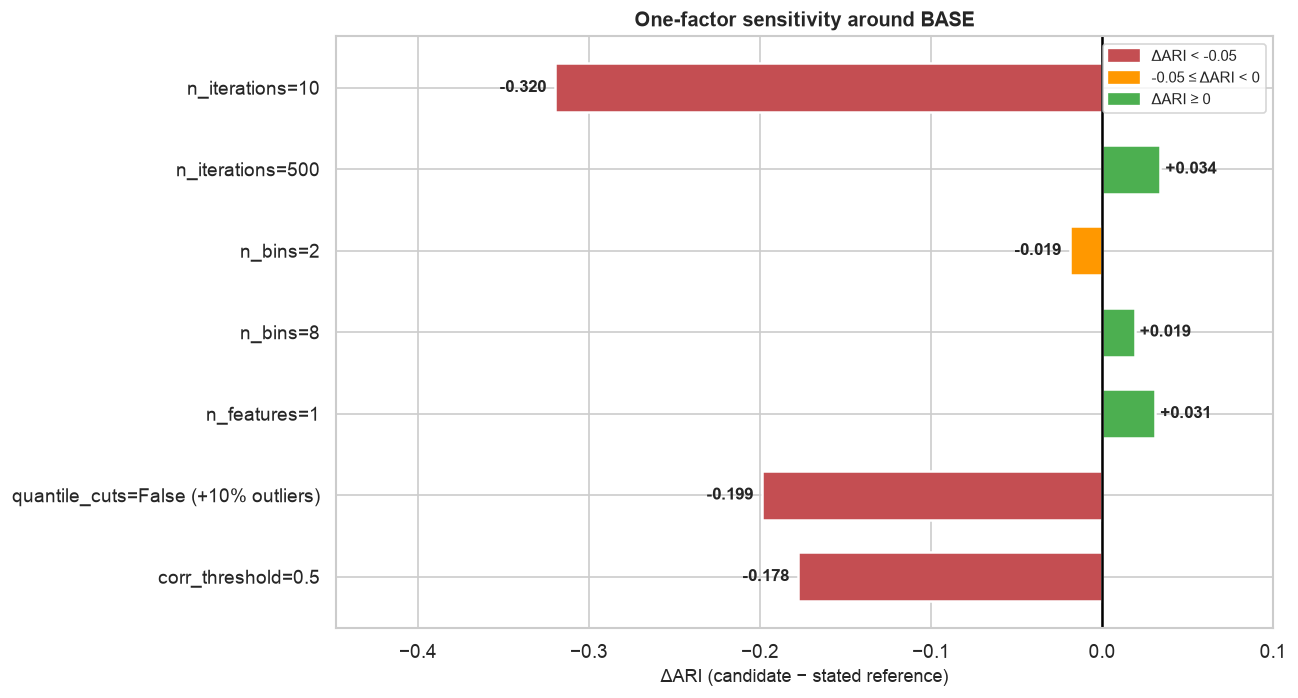

In [22]:
fig, ax = plt.subplots(figsize=(11, 6))
params_s = df_sens.index.tolist()
deltas_s = df_sens['ΔARI'].values.astype(float)
colors_s = ['#C44E52' if d < -0.05 else
            '#FF9800' if d < 0 else
            '#4CAF50' for d in deltas_s]
bars = ax.barh(params_s[::-1], deltas_s[::-1], color=colors_s[::-1],
               edgecolor='white', linewidth=1.5, height=0.6)
ax.axvline(0, color='black', lw=1.5)
for bar, val in zip(bars, deltas_s[::-1]):
    offset = -0.005 if val < 0 else 0.003
    ha = 'right' if val < 0 else 'left'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:+.3f}', ha=ha, va='center',
            fontsize=10, fontweight='bold')
ax.set_xlabel('ΔARI (candidate − stated reference)', fontsize=11)
ax.set_title('One-factor sensitivity around BASE',
             fontsize=12, fontweight='bold')
ax.set_xlim(min(deltas_s) * 1.4, max(0.1, max(deltas_s) * 2))
legend_elems = [
    Patch(color='#C44E52', label='ΔARI < -0.05'),
    Patch(color='#FF9800', label='-0.05 ≤ ΔARI < 0'),
    Patch(color='#4CAF50', label='ΔARI ≥ 0'),
]
ax.legend(handles=legend_elems, fontsize=9)
plt.tight_layout()
plt.show()


## 10. Compute-budget candidates

These three configurations are benchmark candidates, not quality tiers. In particular, more iterations and bins can cost more while producing a lower mean ARI. Choose a budget after measuring seed variability, partition stability, and domain usefulness on your own data.

                     n_iterations  n_bins  ARI mean  ARI std  Time, s
Preset                                                               
low_budget                     50       3     0.856    0.060     0.10
reference                     200       3     0.814    0.137     0.30
high_budget_variant           500       4     0.917    0.035     1.12


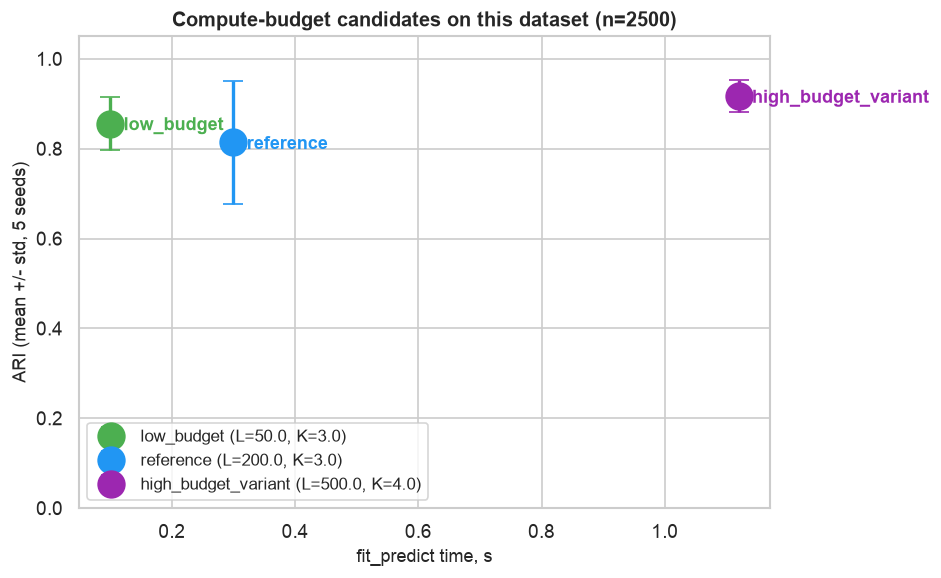

In [23]:
presets = {
    'low_budget': dict(n_iterations=50, n_bins=3),
    'reference': dict(n_iterations=200, n_bins=3),
    'high_budget_variant': dict(n_iterations=500, n_bins=4),
}
preset_rows = []
for name, overrides in presets.items():
    params = {**BASE, **overrides}
    aris, times = [], []
    for s in range(5):
        clf = ForestClusterer(**params, n_clusters=N_CLUSTERS, random_state=s)
        t0 = time.perf_counter()
        lbl = clf.fit_predict(df0)
        times.append(time.perf_counter() - t0)
        aris.append(adjusted_rand_score(y0, lbl))
    preset_rows.append({
        'Preset': name,
        'n_iterations': overrides['n_iterations'],
        'n_bins': overrides['n_bins'],
        'ARI mean': round(np.mean(aris), 3),
        'ARI std': round(np.std(aris), 3),
        'Time, s': round(np.mean(times), 2),
    })
df_pre = pd.DataFrame(preset_rows).set_index('Preset')
print(df_pre.to_string())
fig, ax = plt.subplots(figsize=(8, 5))
colors_pre = ['#4CAF50', '#2196F3', '#9C27B0']
for i, (name, row) in enumerate(df_pre.iterrows()):
    ax.errorbar(row['Time, s'], row['ARI mean'], yerr=row['ARI std'],
                fmt='o', color=colors_pre[i], ms=16, lw=2, capsize=6,
                label=f'{name} (L={row.n_iterations}, K={row.n_bins})')
    ax.annotate(name, (row['Time, s'], row['ARI mean']),
                xytext=(8, -4), textcoords='offset points',
                fontsize=11, fontweight='bold', color=colors_pre[i])
ax.set_xlabel('fit_predict time, s', fontsize=11)
ax.set_ylabel('ARI (mean +/- std, 5 seeds)', fontsize=11)
ax.set_title(f'Compute-budget candidates on this dataset (n={N})',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


## Practical tuning workflow

There is no defensible universal winner in these sweeps. On this very dataset, ARI peaks at `L=400` and then falls at `L=500`, `n_features=1` beats `'sqrt'`, disabling correlation weighting beats `0.9`, adaptive bins are roughly neutral, correlation-aware selection reduces ARI, and 14 jobs are slower than four. KDE cuts and entropy/inverse-Gini weighting improve mean ARI in this run. Those observations are reasons to validate competing variants, not new universal defaults.

A practical workflow is:

1. Start with a modest reproducible reference such as `n_iterations=100–200`, `n_bins=3`, `n_features='sqrt'`, and `n_jobs=1`.
2. Define evaluation criteria before tuning: repeated-seed partition stability, internal indices in a declared space, domain interpretability, and external labels only when they are genuinely held out.
3. Sweep one or two influential parameters over multiple seeds. Treat small differences relative to seed variability as inconclusive.
4. Compare `quantile_cuts` under contamination mechanisms that match the application; do not call it universally robust.
5. Enable correlation weighting only when removing redundant influence matches the modelling goal. Inspect learned groups and compare against `corr_threshold=None`.
6. Treat `adaptive_bins`, `correlation_aware`, KDE cuts, and iteration weighting as alternatives to validate, not automatic final-run upgrades.
7. Benchmark `n_jobs` on the deployment machine.
8. For large `n`, choose a downstream algorithm that does not materialize dense pairwise distances, and measure memory rather than relying only on asymptotic labels.

Finally, keep an untouched validation set or a nested evaluation procedure if labels influence parameter selection. Otherwise the reported ARI is a tuning score, not an unbiased performance estimate.